In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from evaluation_function import evaluate_strategy_full, plot_strategy_vs_buy_hold

# 1. OPTIMIZATION FUNCTION
finding out the threshold for vol ratio based on sharpe ratio and max drawdown. 


In [3]:
def find_best_thresholds(macd_path, boll_path, window=365, step=30, trend_space=None, range_space=None):
    macd_df = pd.read_csv(macd_path)
    boll_df = pd.read_csv(boll_path)
    macd_df['date'] = pd.to_datetime(macd_df['date'])
    boll_df['date'] = pd.to_datetime(boll_df['date'], dayfirst=True)

    df = pd.merge(macd_df[['date', 'price', 'log_return', 'position']],
                  boll_df[['date', 'position']],
                  on='date', suffixes=('_macd', '_boll'))

    df['vol_ratio'] = df['log_return'].rolling(30).std() / df['log_return'].rolling(90).std()
    df['sma_slope'] = df['price'].rolling(20).mean().diff()
    df = df.dropna().reset_index(drop=True)

    if trend_space is None: trend_space = np.arange(0.9, 1.4, 0.05)
    if range_space is None: range_space = np.arange(0.5, 0.9, 0.05)

    # Accumulate scores per param pair across all rolling windows
    score_accumulator = {}

    for start in range(window, len(df) - step, step):
        train = df.iloc[start - window:start]

        for tt in trend_space:
            for rt in range_space:
                if rt >= tt: continue

                regimes, curr = [], 'Trend'
                for ratio in train['vol_ratio']:
                    if ratio > tt: curr = 'Trend'
                    elif ratio < rt: curr = 'Range'
                    regimes.append(curr)

                temp_df = train.copy()
                temp_df['position'] = np.where(np.array(regimes) == 'Trend',
                                               temp_df['position_macd'],
                                               temp_df['position_boll'])
                temp_df.loc[(np.array(regimes) == 'Range') &
                            (temp_df['position_boll'] == 1) &
                            (temp_df['sma_slope'] < 0), 'position'] = 0

                _, _, summary = evaluate_strategy_full(temp_df, fee=0.001, rf_annual=0.03)
                sharpe = summary.get('sharpe_ratio_rf_3pct', -np.inf)
                mdd = abs(summary.get('max_drawdown', 0))
                score = sharpe / (mdd + 1e-6)

                key = (round(float(tt), 2), round(float(rt), 2))
                if key not in score_accumulator:
                    score_accumulator[key] = []
                score_accumulator[key].append(score)

    # Pick the pair with best average score across all windows
    best_key = max(score_accumulator, key=lambda k: np.mean(score_accumulator[k]))
    best_trend_t, best_range_t = best_key
    print(f"Best Trend Thresh: {best_trend_t}, Best Range Thresh: {best_range_t}")
    print(f"Avg score across windows: {np.mean(score_accumulator[best_key]):.4f}")

    return best_trend_t, best_range_t

# 2. FINAL PROCESSING FUNCTION
vol_ratio : 30day sd/ 90day sd
additional rule: prevent long in bollinger when 20day SMA (simple moving average) slope is negative (see a downward trend and refuses to buy)

In [4]:
def process_vol_filter_strategy(macd_path, boll_path, output_csv, trend_t, range_t):
    """
    Outputs the final post-trade table with strategy source column.
    """
    macd_df = pd.read_csv(macd_path)
    boll_df = pd.read_csv(boll_path)
    macd_df['date'] = pd.to_datetime(macd_df['date'], format='mixed')
    boll_df['date'] = pd.to_datetime(boll_df['date'], format='mixed',dayfirst=True)
    
    df = pd.merge(macd_df[['date', 'price', 'log_return', 'position']], 
                  boll_df[['date', 'position']], 
                  on='date', suffixes=('_macd', '_boll'))
    df = df.sort_values('date').reset_index(drop=True)
    

    df['vol_ratio'] = df['log_return'].rolling(30).std() / df['log_return'].rolling(90).std()
    df['sma_slope'] = df['price'].rolling(20).mean().diff()
    
    # Calculate Regime with Hysteresis
    regimes, current = [], 'Trend'
    for val in df['vol_ratio']:
        if val > trend_t: current = 'Trend'
        elif val < range_t: current = 'Range'
        regimes.append(current)
    df['regime'] = regimes
    
    # Source Tracking & Position Logic
    def apply_rules(row):
        if row['regime'] == 'Trend':
            return row['position_macd'], 'macd'
        else:
            if row['position_boll'] == 1 and row['sma_slope'] < 0:
                return 0, 'neutral'
            return row['position_boll'], 'bolling'
            
    res = df.apply(apply_rules, axis=1)
    df['position'] = [x[0] for x in res]
    df['strategy_source'] = [x[1] for x in res]
    
    # Re-generate trade actions
    df['trade'] = df['position'].diff().fillna(0).astype(int)
    df['trade_action'] = df['trade'].map({1: 'buy', -1: 'sell', 0: 'hold'})
    
    # Save output
    output_cols = ['date', 'price', 'log_return', 'trade', 'trade_action', 'position', 'strategy_source']
    df[output_cols].to_csv(output_csv, index=False)
    return df

# --- RUN EXECUTION ---
below is an example run with eth 

Optimizing thresholds...
Best Trend Thresh: 0.9, Best Range Thresh: 0.5
Avg score across windows: 2.7987
Date range: 2018-01-01 00:00:00 → 2025-12-30 00:00:00
Total rows: 2921
Equity check (strategy): 14.104702036189734
Equity check (buy&hold): 3.845792265551263

--- Final Strategy Performance ---
cumulative_pnl: 13.1047
average_daily_pnl: 0.0014
max_drawdown: -0.6639
annualised_return: 0.3919
sharpe_ratio_rf_3pct: 0.8044
daily_std_dev: 0.0308
annualised_volatility: 0.5890
exposure_rate: 0.4998
total_turnover: 141.0000
number_of_trades_total: 71.0000
number_of_complete_trades: 70.0000
win_rate: 0.4429
average_trade_return: 0.0650
median_trade_return: -0.0222
average_win_return: 0.2766
average_loss_return: -0.1031
profit_factor: 2.1318
payoff_ratio: 2.6819
expectancy_per_trade: 0.0650
best_trade: 0.8243
worst_trade: -0.3324
average_holding_periods: 20.4143
median_holding_periods: 18.5000
long_trades: 63.0000
short_trades: 7.0000


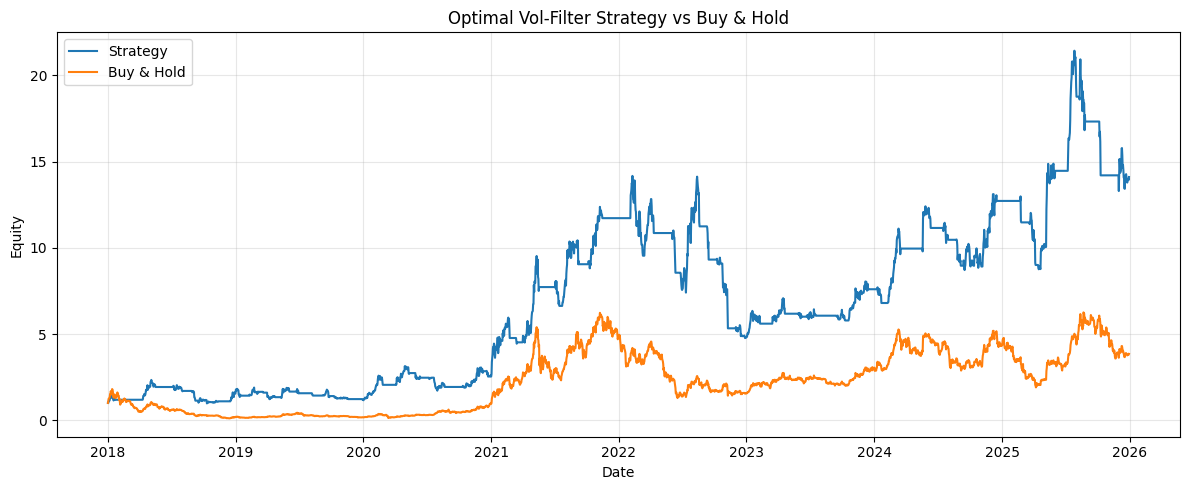

In [5]:
# Step 1: Find best parameters
print("Optimizing thresholds...")
best_trend_t, best_range_t = find_best_thresholds(
    '../datasets/eth_macd_18_50_13_post_trade_table.csv', 
    '../datasets/eth_bollinger_post_trade_table.csv'
)

# Step 2: Load and merge data once
window = 365
step = 30

macd_df = pd.read_csv('../datasets/eth_macd_18_50_13_post_trade_table.csv')
boll_df = pd.read_csv('../datasets/eth_bollinger_post_trade_table.csv')
macd_df['date'] = pd.to_datetime(macd_df['date'], format='mixed')
boll_df['date'] = pd.to_datetime(boll_df['date'], format='mixed', dayfirst=True)

df = pd.merge(
    macd_df[['date','price','log_return','position']],
    boll_df[['date','position']],
    on='date', suffixes=('_macd','_boll')
).reset_index(drop=True)

df['vol_ratio'] = df['log_return'].rolling(30).std() / df['log_return'].rolling(90).std()
df['sma_slope'] = df['price'].rolling(20).mean().diff()

# Step 3: Apply global best params to the full dataset 
final_df = process_vol_filter_strategy(
    macd_path='../datasets/eth_macd_18_50_13_post_trade_table.csv',
    boll_path='../datasets/eth_bollinger_post_trade_table.csv',
    output_csv='vol_filter_post_trade.csv',
    trend_t=best_trend_t,
    range_t=best_range_t
)

print(f"Date range: {final_df['date'].min()} → {final_df['date'].max()}")
print(f"Total rows: {len(final_df)}")

# Step 4: Evaluate
asset_ret = final_df['price'].pct_change().fillna(0)
strat_ret = final_df['position'] * asset_ret
print("Equity check (strategy):", (1 + strat_ret).cumprod().iloc[-1])
print("Equity check (buy&hold):", (1 + asset_ret).cumprod().iloc[-1])

eval_df = final_df[['date', 'price', 'log_return', 'position', 'trade']].copy()
daily_eval, trade_log, summary = evaluate_strategy_full(eval_df, fee=0.00, rf_annual=0.03)
print("\n--- Final Strategy Performance ---")
for k, v in summary.items():
    print(f"{k}: {v:.4f}")

plot_strategy_vs_buy_hold(daily_eval, title="Optimal Vol-Filter Strategy vs Buy & Hold")
plt.show()